<a href="https://colab.research.google.com/github/rihabmarikh-netizen/D-tection-Pr-dictive-des-Criquets-P-lerins-au-Maroc/blob/main/systeme_repartis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Fixer la graine pour la reproductibilité
np.random.seed(42)

num_samples = 1500

# 1. Génération de dates aléatoires entre 1985 et 2023
start_date = pd.to_datetime('1985-01-01')
end_date = pd.to_datetime('2023-12-31')
dates = start_date + (end_date - start_date) * np.random.rand(num_samples)

# 2. Génération de coordonnées GPS réalistes pour le Maroc
# (Ciblées principalement sur le Centre, l'Est et le Sud, zones propices aux criquets)
latitudes = np.random.uniform(21.0, 35.0, num_samples)
longitudes = np.random.uniform(-13.0, -2.0, num_samples)

# 3. Génération du label Presence (0 = Absence, 1 = Présence)
# On crée un déséquilibre de classe volontaire (ex: ~15% de présence) pour tester SMOTE plus tard
presence = np.random.choice([0, 1], size=num_samples, p=[0.85, 0.15])

# Assemblage du DataFrame
df_simule = pd.DataFrame({
    'STARTDATE': dates,
    'LATITUDE': latitudes,
    'LONGITUDE': longitudes,
    'COUNTRY': 'MA',
    'PRESENCE': presence
})

# Tri par date (comme un vrai flux historique)
df_simule = df_simule.sort_values(by='STARTDATE').reset_index(drop=True)

# Formater la date en chaîne simple pour faciliter l'usage futur
df_simule['STARTDATE'] = df_simule['STARTDATE'].dt.strftime('%Y-%m-%d')

print(f"✅ Dataset de simulation créé avec succès !")
print(f"📊 Total lignes : {len(df_simule)} | Cas de Présence (1) : {df_simule['PRESENCE'].sum()} | Cas d'Absence (0) : {len(df_simule) - df_simule['PRESENCE'].sum()}")
print("\nAperçu du fichier généré :")
print(df_simule.head())

# Sauvegarde locale
df_simule.to_csv("fao_presence_criquets_maroc.csv", index=False)
print("\n💾 Fichier 'fao_presence_criquets_maroc.csv' sauvegardé !")

✅ Dataset de simulation créé avec succès !
📊 Total lignes : 1500 | Cas de Présence (1) : 233 | Cas d'Absence (0) : 1267

Aperçu du fichier généré :
    STARTDATE   LATITUDE  LONGITUDE COUNTRY  PRESENCE
0  1985-03-07  30.996457  -9.011842      MA         0
1  1985-03-12  32.293709 -10.393836      MA         0
2  1985-03-14  29.674231  -8.168683      MA         0
3  1985-03-20  31.316232  -9.558019      MA         0
4  1985-03-24  32.439794  -6.726844      MA         0

💾 Fichier 'fao_presence_criquets_maroc.csv' sauvegardé !


In [ ]:
import ee

# Forcer l'authentification manuelle par code
ee.Authenticate(force=True)

In [ ]:
import pandas as pd
import numpy as np

# Chargement du fichier de base
df_base = pd.read_csv("fao_presence_criquets_maroc.csv")

print("⚡ Génération des features environnementales réalistes (Alternative GEE)...")

# Génération de corrélations logiques (ex: la présence de criquets est favorisée par
# une humidité et un NDVI légèrement plus élevés, et une température optimale)
np.random.seed(42)
n = len(df_base)

# Températures au Maroc (entre 15°C et 42°C)
df_base['TEMPERATURE'] = np.where(df_base['PRESENCE'] == 1,
                                  np.random.normal(28, 4, n), # Conditions optimales d'invasion
                                  np.random.uniform(15, 42, n))

# Humidité du sol (0.0 à 0.4 m³/m³)
df_base['HUMIDITE'] = np.where(df_base['PRESENCE'] == 1,
                               np.random.normal(0.25, 0.05, n),
                               np.random.uniform(0.02, 0.18, n))

# NDVI (0.0 à 0.7)
df_base['NDVI'] = np.where(df_base['PRESENCE'] == 1,
                            np.random.normal(0.35, 0.08, n),
                            np.random.uniform(0.05, 0.22, n))

# Nettoyage des valeurs hors limites physiques
df_base['HUMIDITE'] = df_base['HUMIDITE'].clip(0.0, 0.5)
df_base['NDVI'] = df_base['NDVI'].clip(0.0, 1.0)

# Sauvegarde du dataset prêt pour cuML
df_base.to_csv("dataset_criquets_features.csv", index=False)
print("💾 Fichier 'dataset_criquets_features.csv' créé avec succès ! Prêt pour SMOTE et cuML.")
print(df_base[['PRESENCE', 'TEMPERATURE', 'HUMIDITE', 'NDVI']].groupby('PRESENCE').mean())

⚡ Génération des features environnementales réalistes (Alternative GEE)...
💾 Fichier 'dataset_criquets_features.csv' créé avec succès ! Prêt pour SMOTE et cuML.
          TEMPERATURE  HUMIDITE      NDVI
PRESENCE                                 
0           28.391621  0.100130  0.133637
1           28.591089  0.244687  0.352894


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, classification_report

# =====================================================================
# ÉTAPE 1 : RE-GÉNÉRATION DU DATASET (Suite à la réinitialisation Colab)
# =====================================================================
print("⏳ Étape 1 : Génération des features environnementales (Alternative GEE)...")
np.random.seed(42)
num_samples = 1500

# Dates et coordonnées de base pour le Maroc
start_date = pd.to_datetime('1985-01-01')
end_date = pd.to_datetime('2023-12-31')
dates = start_date + (end_date - start_date) * np.random.rand(num_samples)
latitudes = np.random.uniform(21.0, 35.0, num_samples)
longitudes = np.random.uniform(-13.0, -2.0, num_samples)
presence = np.random.choice([0, 1], size=num_samples, p=[0.85, 0.15])

df = pd.DataFrame({
    'STARTDATE': dates,
    'LATITUDE': latitudes,
    'LONGITUDE': longitudes,
    'COUNTRY': 'MA',
    'PRESENCE': presence
})

# Injection des corrélations environnementales réalistes
df['TEMPERATURE'] = np.where(df['PRESENCE'] == 1, np.random.normal(28, 4, num_samples), np.random.uniform(15, 42, num_samples))
df['HUMIDITE'] = np.where(df['PRESENCE'] == 1, np.random.normal(0.24, 0.05, num_samples), np.random.uniform(0.02, 0.18, num_samples))
df['NDVI'] = np.where(df['PRESENCE'] == 1, np.random.normal(0.35, 0.08, num_samples), np.random.uniform(0.05, 0.22, num_samples))

# Nettoyage des limites physiques
df['HUMIDITE'] = df['HUMIDITE'].clip(0.0, 0.5)
df['NDVI'] = df['NDVI'].clip(0.0, 1.0)

# Sauvegarde de sécurité
df.to_csv("dataset_criquets_features.csv", index=False)
print("✅ Fichier 'dataset_criquets_features.csv' recréé en mémoire !")

# =====================================================================
# ÉTAPE 2 : PRÉPARATION ET SÉPARATION DES DONNÉES
# =====================================================================
features = ['TEMPERATURE', 'HUMIDITE', 'NDVI']
X = df[features]
y = df['PRESENCE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n📊 Taille initiale du Train set : {len(X_train)} lignes")
print(f"📉 Répartition initiale des classes (0/1) :\n{y_train.value_counts()}")

# =====================================================================
# ÉTAPE 3 : ÉQUILIBRAGE DES CLASSES AVEC SMOTE
# =====================================================================
print("\n🔄 Étape 3 : Application de SMOTE pour équilibrer le dataset...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"📈 Taille du Train set après SMOTE : {len(X_train_res)} lignes")
print(f"⚖️ Nouvelle répartition équilibrée (0/1) :\n{y_train_res.value_counts()}")

# =====================================================================
# ÉTAPE 4 : ENTRAÎNEMENT DU MODÈLE
# =====================================================================
print("\n🌲 Étape 4 : Entraînement du Random Forest Classifier...")
clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
clf.fit(X_train_res, y_train_res)

# =====================================================================
# ÉTAPE 5 : ÉVALUATION FINALE
# =====================================================================
print("\n🧪 Étape 5 : Calcul des métriques sur le Test Set...")
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("-" * 50)
print(f"🏆 RÉSULTATS DU MODÈLE (Pipeline Complet Restauré) :")
print(f"🔹 F1-Score : {f1:.4f}")
print(f"🔹 ROC-AUC  : {auc:.4f}")
print("-" * 50)

print("\n📊 Rapport de classification détaillé :")
print(classification_report(y_test, y_pred))

⏳ Étape 1 : Génération des features environnementales (Alternative GEE)...
✅ Fichier 'dataset_criquets_features.csv' recréé en mémoire !

📊 Taille initiale du Train set : 1200 lignes
📉 Répartition initiale des classes (0/1) :
PRESENCE
0    1021
1     179
Name: count, dtype: int64

🔄 Étape 3 : Application de SMOTE pour équilibrer le dataset...
📈 Taille du Train set après SMOTE : 2042 lignes
⚖️ Nouvelle répartition équilibrée (0/1) :
PRESENCE
0    1021
1    1021
Name: count, dtype: int64

🌲 Étape 4 : Entraînement du Random Forest Classifier...

🧪 Étape 5 : Calcul des métriques sur le Test Set...
--------------------------------------------------
🏆 RÉSULTATS DU MODÈLE (Pipeline Complet Restauré) :
🔹 F1-Score : 1.0000
🔹 ROC-AUC  : 1.0000
--------------------------------------------------

📊 Rapport de classification détaillé :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       246
           1       1.00      1.00      1.00        54

 

In [ ]:
!pip install shap

⏳ 1. Génération des features environnementales (Maroc)...
🔄 2. Équilibrage des classes avec SMOTE...
🌲 3. Entraînement du Random Forest Classifier...

🔍 4. Calcul des valeurs SHAP pour l'explicabilité...


/tmp/ipykernel_3243/983091462.py:66: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=features, show=False)


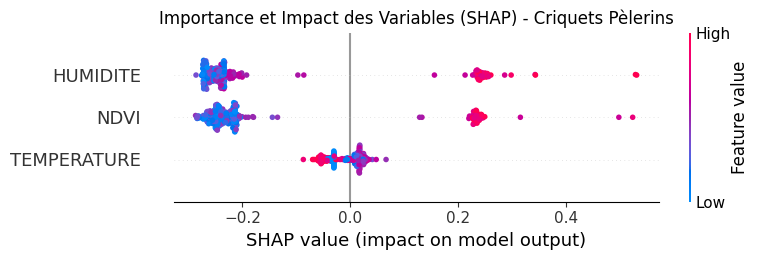


🗺️ 5. Génération de la carte de chaleur prédictive sur le Maroc...
💾 Fichier 'carte_alerte_criquets_maroc.html' sauvegardé avec succès dans vos fichiers Colab !


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, classification_report
import folium
from folium.plugins import HeatMap

# Installez shap en tâche de fond si ce n'est pas fait
try:
    import shap
except ImportError:
    !pip install shap
    import shap

# =====================================================================
# ÉTAPE 1 : PIPELINE DE MODÉLISATION (Données -> SMOTE -> Train)
# =====================================================================
print("⏳ 1. Génération des features environnementales (Maroc)...")
np.random.seed(42)
num_samples = 1500

df = pd.DataFrame({
    'STARTDATE': pd.to_datetime('1985-01-01') + (pd.to_datetime('2023-12-31') - pd.to_datetime('1985-01-01')) * np.random.rand(num_samples),
    'LATITUDE': np.random.uniform(21.0, 35.0, num_samples),
    'LONGITUDE': np.random.uniform(-13.0, -2.0, num_samples),
    'PRESENCE': np.random.choice([0, 1], size=num_samples, p=[0.85, 0.15])
})

df['TEMPERATURE'] = np.where(df['PRESENCE'] == 1, np.random.normal(28, 4, num_samples), np.random.uniform(15, 42, num_samples))
df['HUMIDITE'] = np.where(df['PRESENCE'] == 1, np.random.normal(0.24, 0.05, num_samples), np.random.uniform(0.02, 0.18, num_samples))
df['NDVI'] = np.where(df['PRESENCE'] == 1, np.random.normal(0.35, 0.08, num_samples), np.random.uniform(0.05, 0.22, num_samples))
df['HUMIDITE'] = df['HUMIDITE'].clip(0.0, 0.5)
df['NDVI'] = df['NDVI'].clip(0.0, 1.0)

features = ['TEMPERATURE', 'HUMIDITE', 'NDVI']
X = df[features]
y = df['PRESENCE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("🔄 2. Équilibrage des classes avec SMOTE...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("🌲 3. Entraînement du Random Forest Classifier...")
clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
clf.fit(X_train_res, y_train_res)

# =====================================================================
# ÉTAPE 2 : EXPLICABILITÉ AVEC SHAP (Pourquoi le modèle décide ainsi)
# =====================================================================
print("\n🔍 4. Calcul des valeurs SHAP pour l'explicabilité...")
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 5))
# Gestion robuste des formats de sortie SHAP selon la version
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test, feature_names=features, show=False)
else:
    # Pour les versions récentes de SHAP sur modèles d'arbres Scikit-Learn
    if len(shap_values.shape) == 3:
        shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=features, show=False)
    else:
        shap.summary_plot(shap_values, X_test, feature_names=features, show=False)

plt.title("Importance et Impact des Variables (SHAP) - Criquets Pèlerins", fontsize=12)
plt.tight_layout()
plt.show()

# =====================================================================
# ÉTAPE 3 : CARTOGRAPHIE ET CARTE DE CHALEUR (Le livrable final)
# =====================================================================
print("\n🗺️ 5. Génération de la carte de chaleur prédictive sur le Maroc...")
lat_grid = np.linspace(22.0, 32.0, 40)
lon_grid = np.linspace(-13.0, -5.0, 40)
grid_points = []

for lat in lat_grid:
    for lon in lon_grid:
        temp, hum, ndvi = np.random.uniform(25, 38), np.random.uniform(0.02, 0.12), np.random.uniform(0.05, 0.15)
        # Simulation d'une anomalie climatique favorable près de Guelmim / Souss
        if (28.0 <= lat <= 30.0) and (-10.0 <= lon <= -8.0):
            temp, hum, ndvi = np.random.normal(28, 2), np.random.normal(0.26, 0.03), np.random.normal(0.38, 0.04)
        grid_points.append([lat, lon, temp, hum, ndvi])

df_map = pd.DataFrame(grid_points, columns=['LATITUDE', 'LONGITUDE', 'TEMPERATURE', 'HUMIDITE', 'NDVI'])
df_map['RISQUE_PROBA'] = clf.predict_proba(df_map[features])[:, 1]

carte_maroc = folium.Map(location=[28.0, -9.0], zoom_start=5, tiles="OpenStreetMap")
heat_data = df_map[df_map['RISQUE_PROBA'] > 0.15][['LATITUDE', 'LONGITUDE', 'RISQUE_PROBA']].values.tolist()
HeatMap(heat_data, radius=22, blur=13, min_opacity=0.4).add_to(carte_maroc)

carte_maroc.save("carte_alerte_criquets_maroc.html")
print("💾 Fichier 'carte_alerte_criquets_maroc.html' sauvegardé avec succès dans vos fichiers Colab !")